In [1]:
# Mata Kuliah Data Mining
# Kelompok 6 - SI4802
# Anggota:
# 102022430036 - Muhammad Daffa Izzati
# 102022400329 - Muhammad Daffa Reifansya
# 102022400325 - Kevin Muhammad Althaf
# 102022430069 - Sekar Erliana Putri

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.model_selection import GridSearchCV
import joblib

In [3]:
# Read Dari Kaggle
# df = pd.read_csv('/kaggle/input/datasets/arjunbhasin2013/ccdata/CC GENERAL.csv')

# Read dari VSCODE
df = pd.read_csv('CC GENERAL.csv')

# EDA

In [4]:
display(df.head())

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [5]:
print(f"Jumlah Record (Baris) : {df.shape[0]}")
print(f"Jumlah Variabel (Kolom): {df.shape[1]}\n")

Jumlah Record (Baris) : 8950
Jumlah Variabel (Kolom): 18



In [6]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

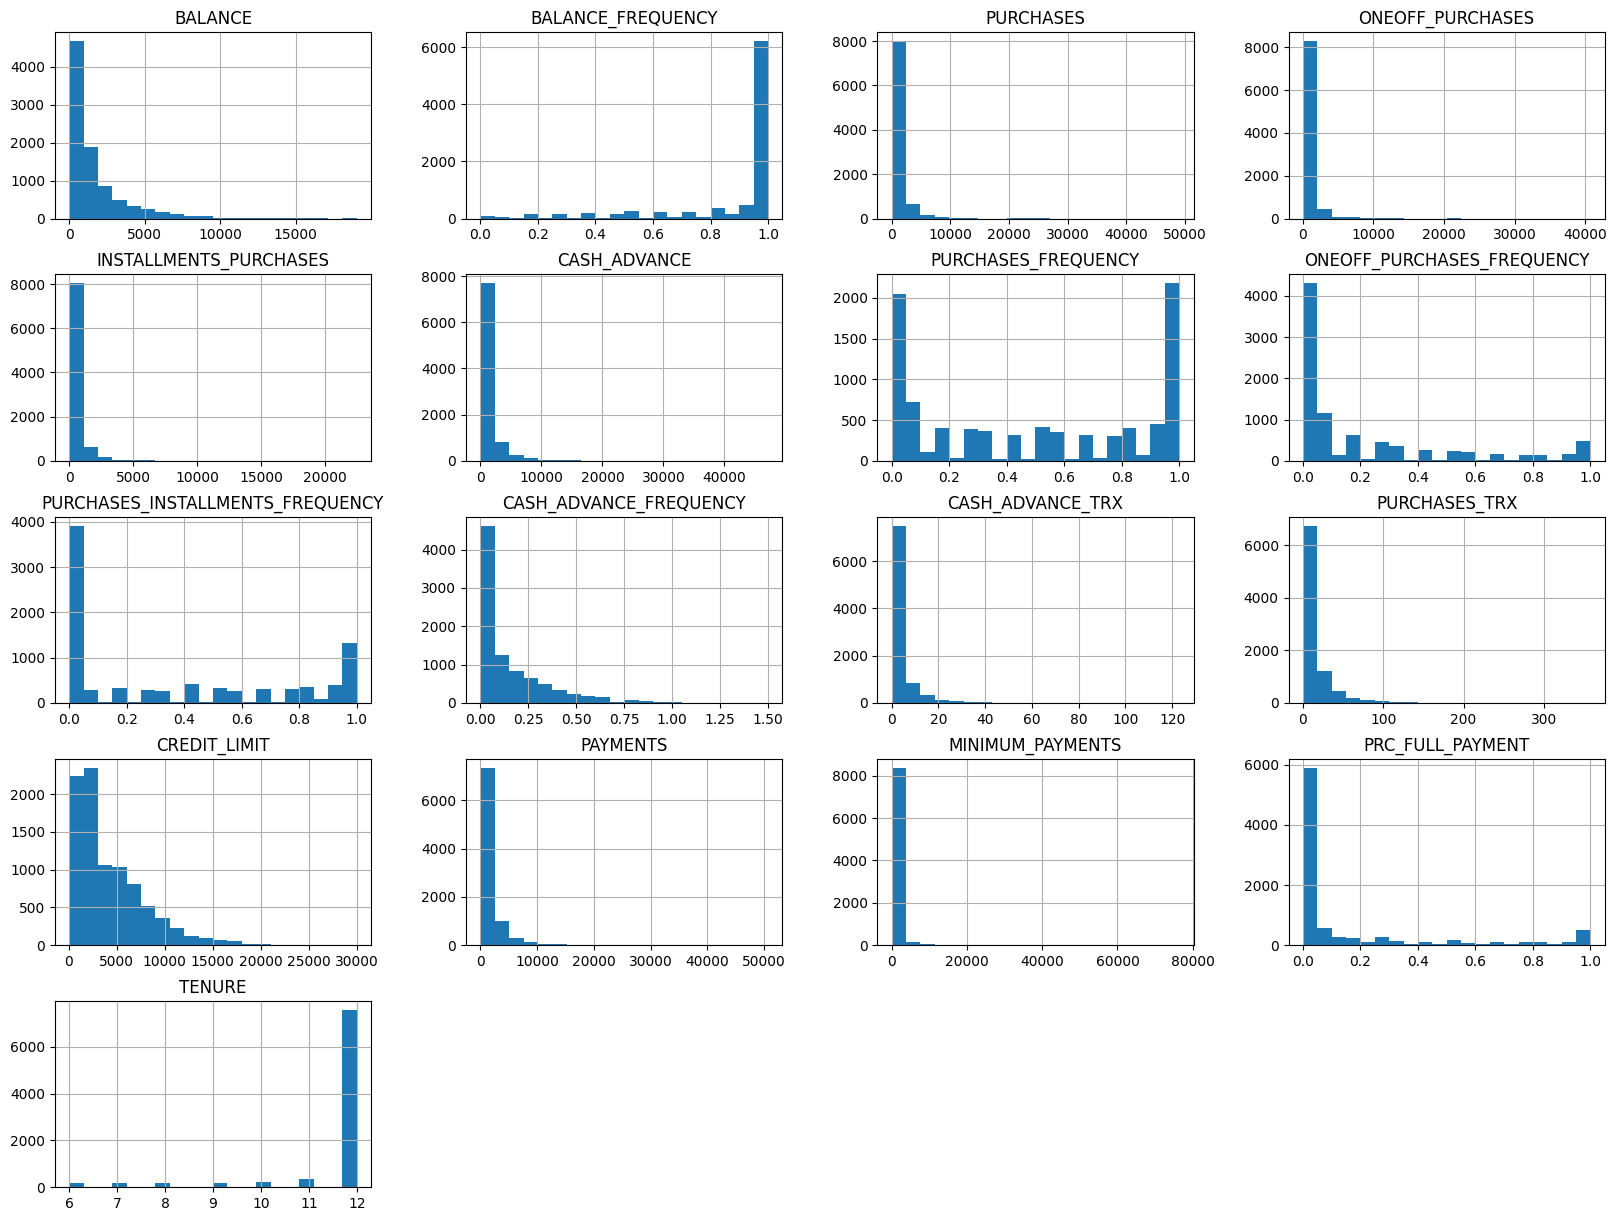

In [8]:
df.hist(bins=20, figsize=(20, 15))
plt.show()

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

# DATA PREPARATION 

In [11]:
df_prepared = df.drop(columns=['CUST_ID'])

In [12]:
display(df_prepared)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [13]:
df_prepared['MINIMUM_PAYMENTS'] = df_prepared['MINIMUM_PAYMENTS'].fillna(df_prepared['MINIMUM_PAYMENTS'].median())
df_prepared['CREDIT_LIMIT'] = df_prepared['CREDIT_LIMIT'].fillna(df_prepared['CREDIT_LIMIT'].median())

In [14]:
df_prepared.isnull().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

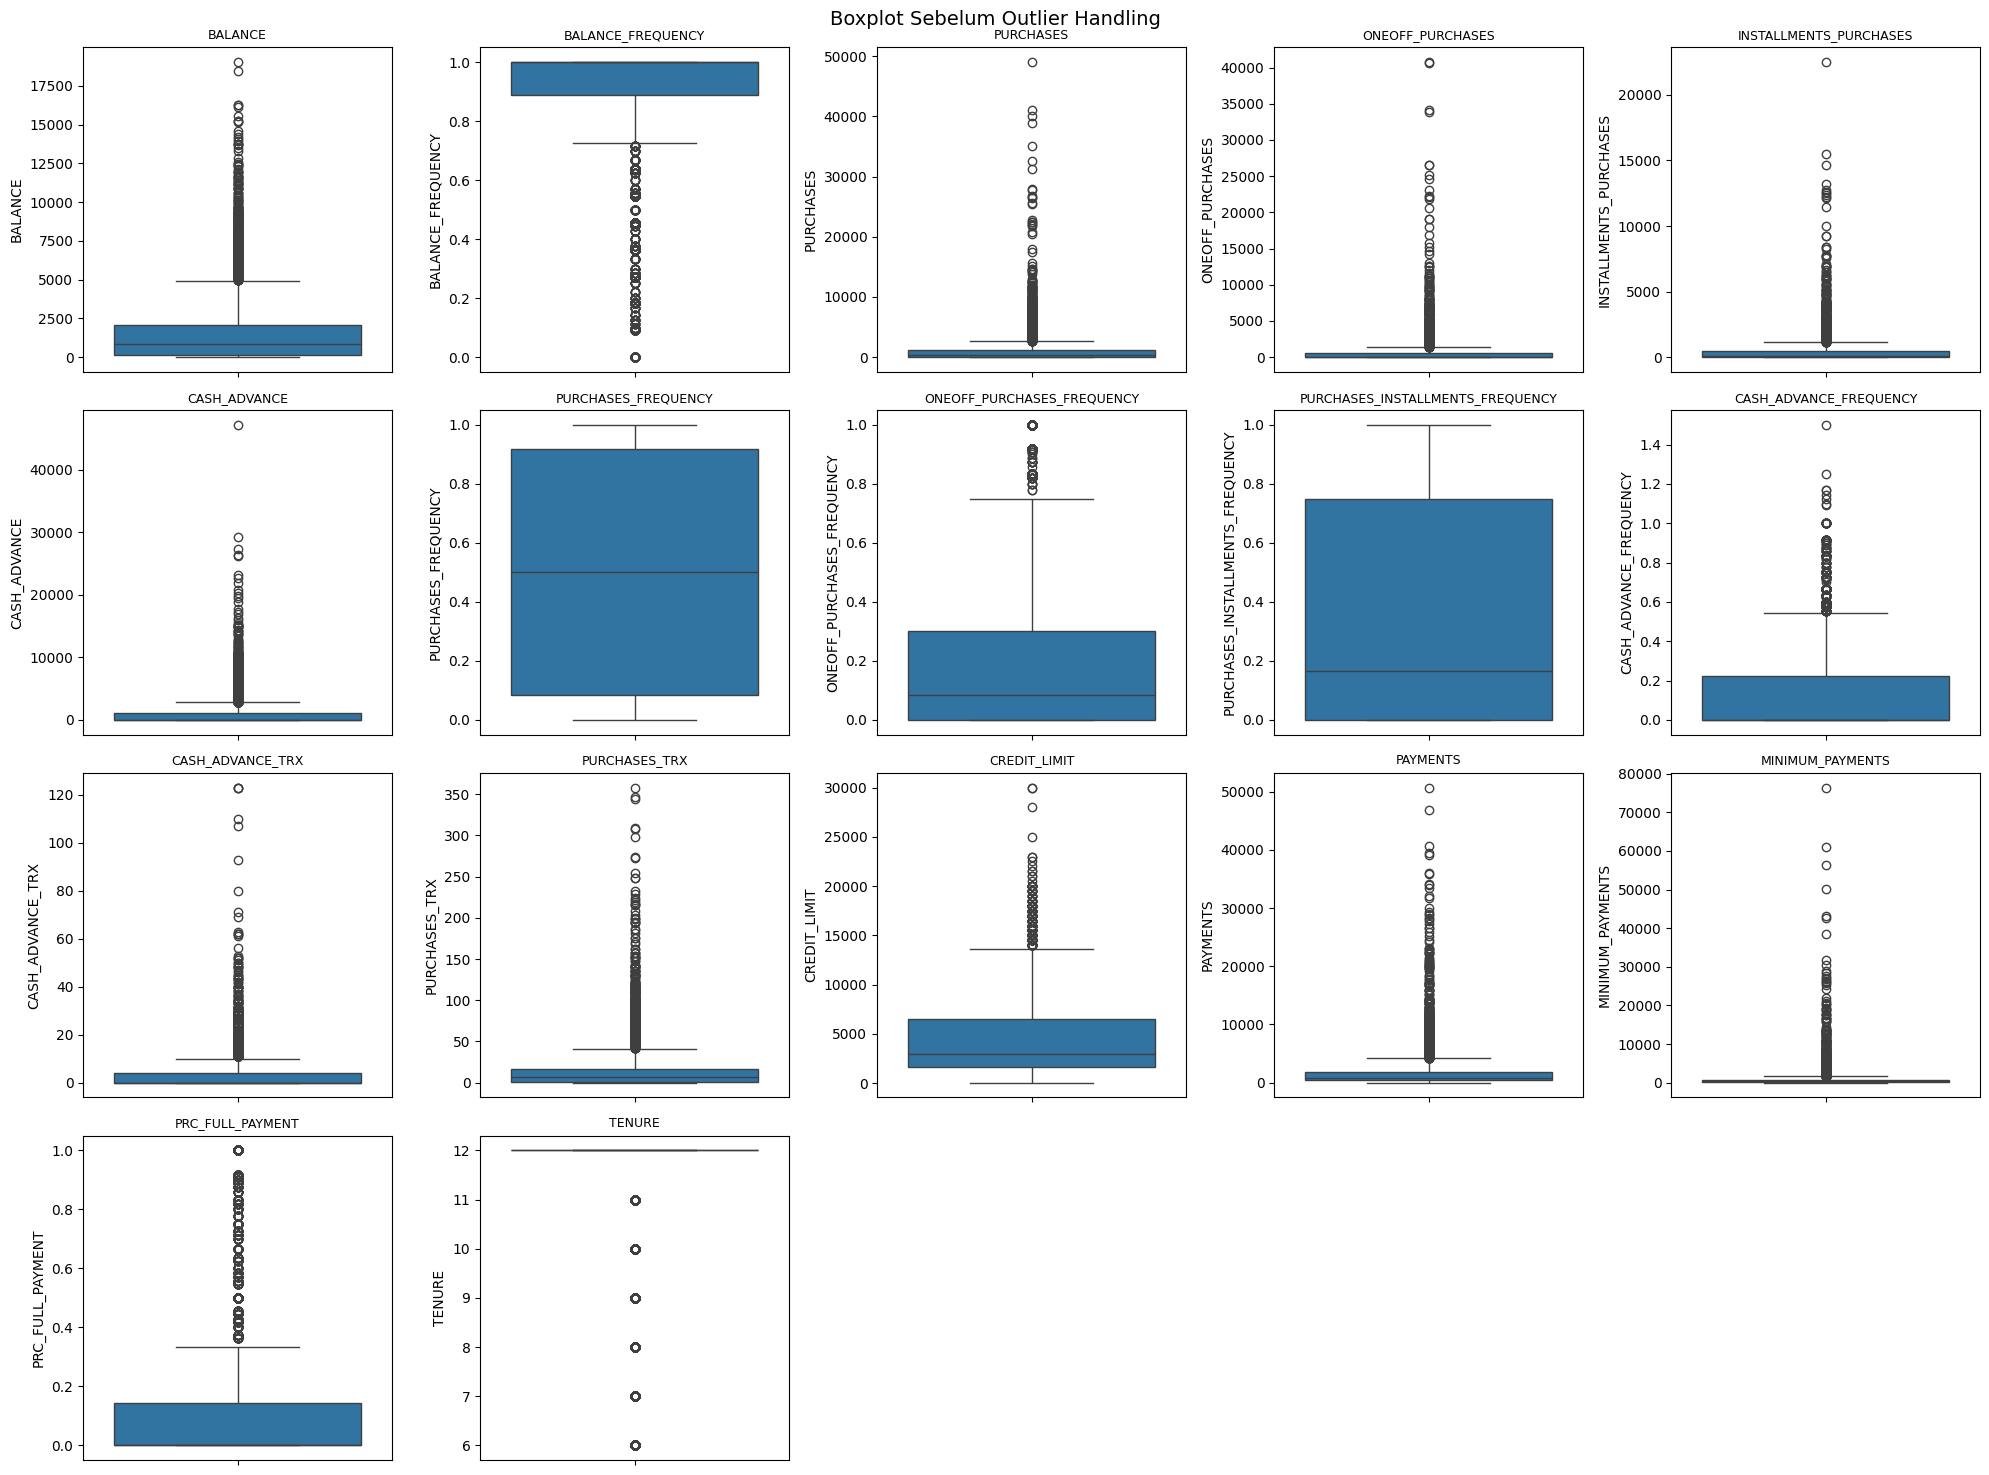

In [15]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(df_prepared.columns):
    plt.subplot(4, 5, i + 1)
    sns.boxplot(y=df_prepared[col])
    plt.title(col, fontsize=9)
plt.suptitle('Boxplot Sebelum Outlier Handling', fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
df_clean = df_prepared.copy()

for col in df_clean.columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_count = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
    print(f"{col}: {outlier_count} outlier ditemukan")
    
    df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)

print(f"\nShape sebelum: {df_prepared.shape}")
print(f"Shape sesudah: {df_clean.shape}")

BALANCE: 695 outlier ditemukan
BALANCE_FREQUENCY: 1493 outlier ditemukan
PURCHASES: 808 outlier ditemukan
ONEOFF_PURCHASES: 1013 outlier ditemukan
INSTALLMENTS_PURCHASES: 867 outlier ditemukan
CASH_ADVANCE: 1030 outlier ditemukan
PURCHASES_FREQUENCY: 0 outlier ditemukan
ONEOFF_PURCHASES_FREQUENCY: 782 outlier ditemukan
PURCHASES_INSTALLMENTS_FREQUENCY: 0 outlier ditemukan
CASH_ADVANCE_FREQUENCY: 525 outlier ditemukan
CASH_ADVANCE_TRX: 804 outlier ditemukan
PURCHASES_TRX: 766 outlier ditemukan
CREDIT_LIMIT: 248 outlier ditemukan
PAYMENTS: 808 outlier ditemukan
MINIMUM_PAYMENTS: 909 outlier ditemukan
PRC_FULL_PAYMENT: 1474 outlier ditemukan
TENURE: 1366 outlier ditemukan

Shape sebelum: (8950, 17)
Shape sesudah: (8950, 17)


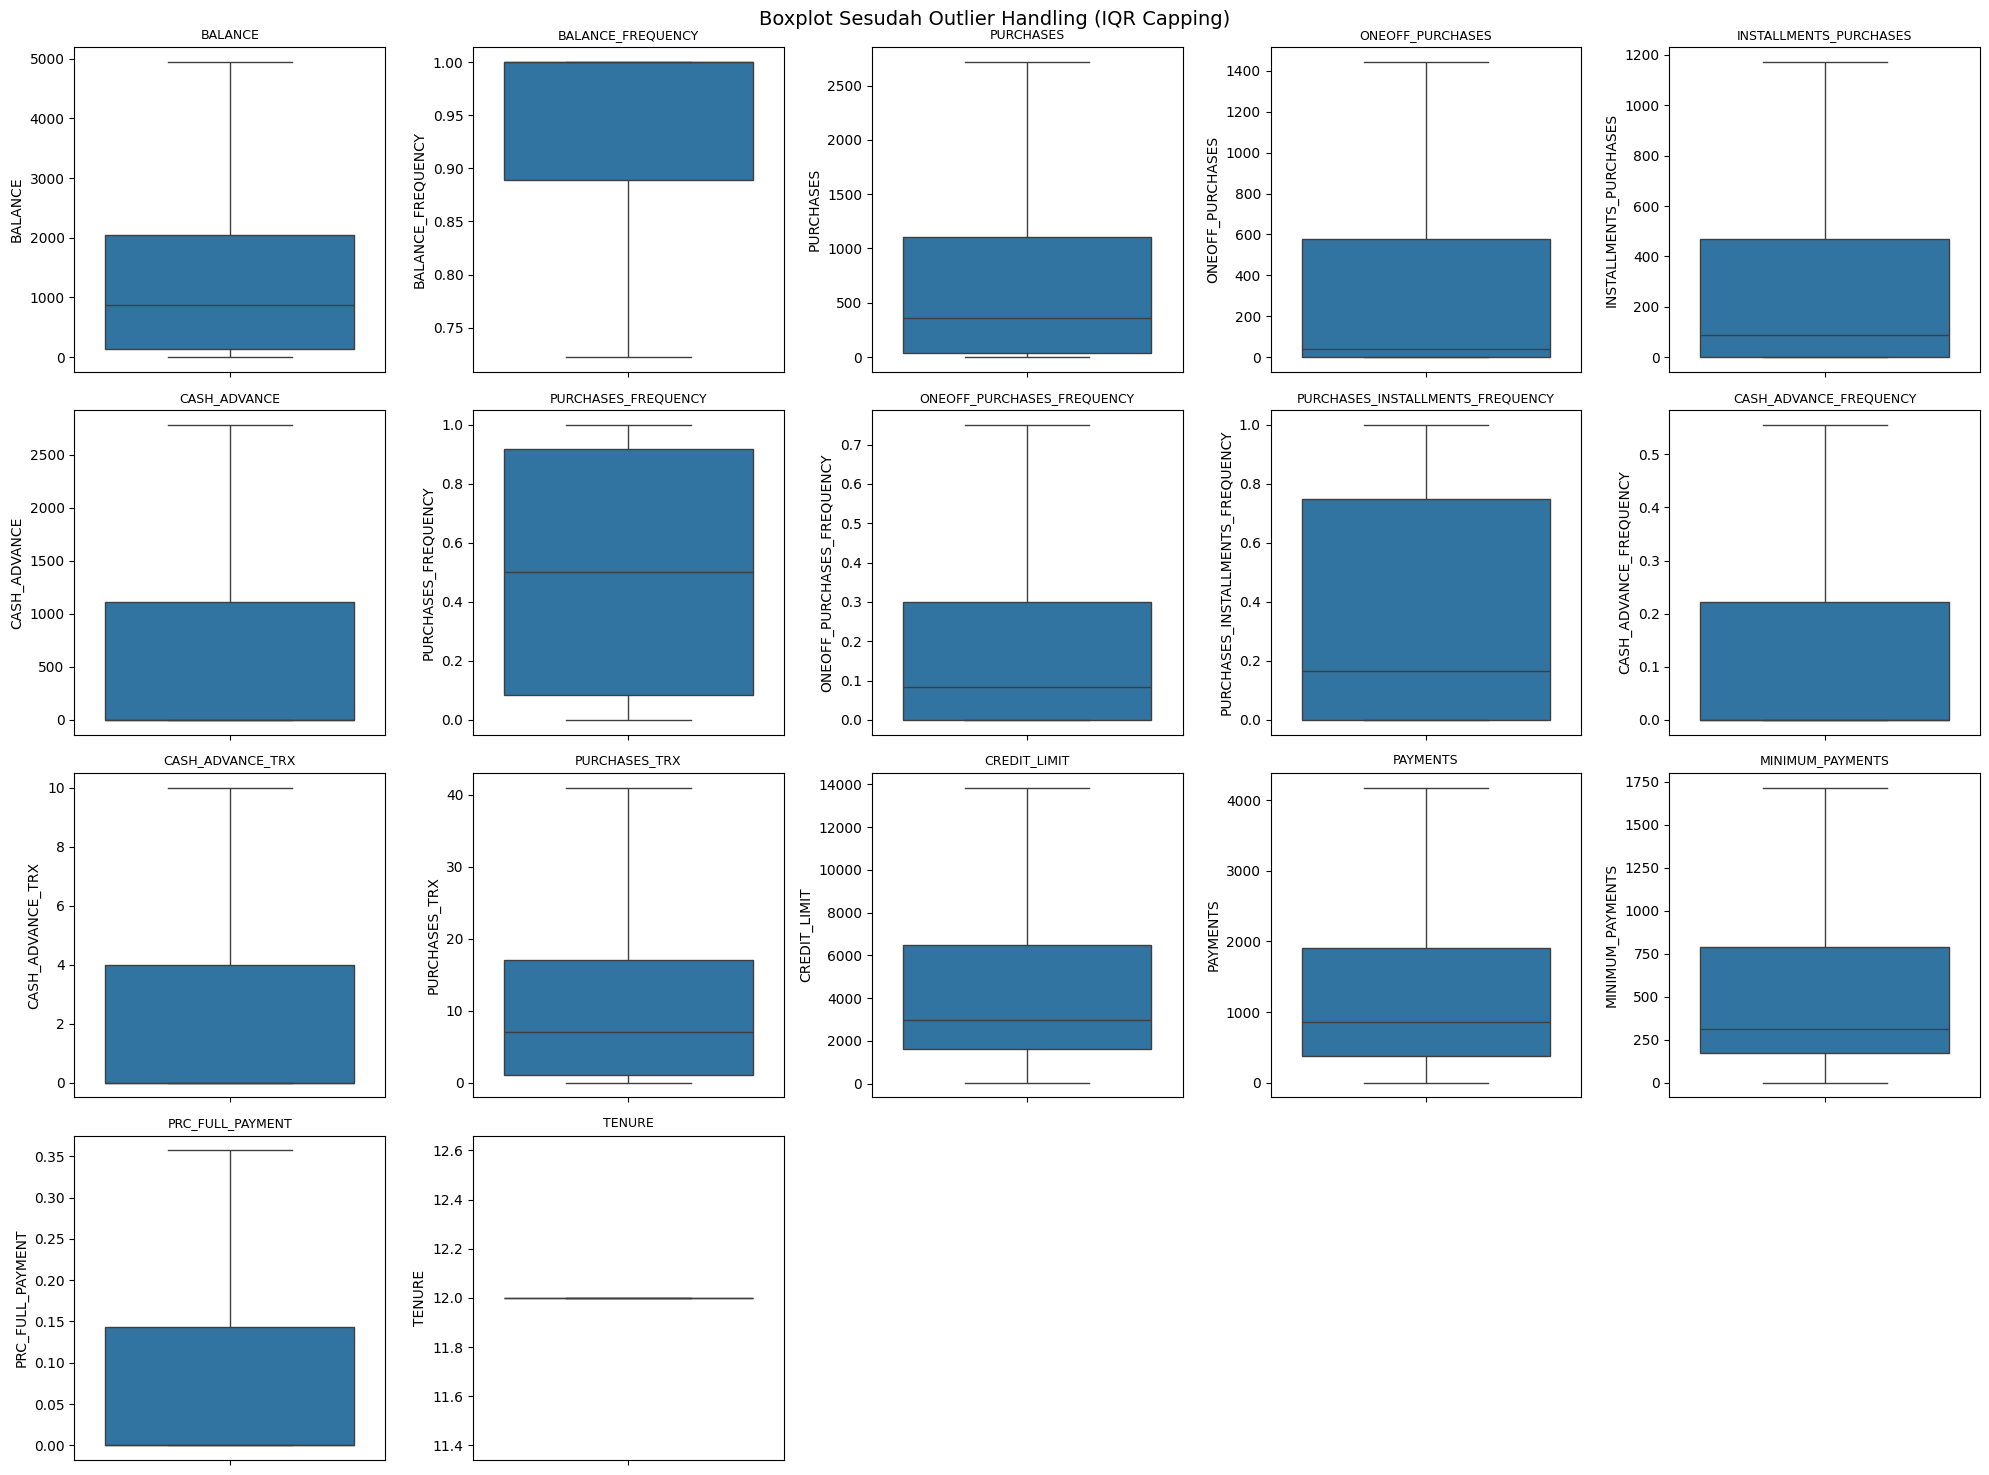

In [17]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(df_clean.columns):
    plt.subplot(4, 5, i + 1)
    sns.boxplot(y=df_clean[col])
    plt.title(col, fontsize=9)
plt.suptitle('Boxplot Sesudah Outlier Handling (IQR Capping)', fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_clean), columns=df_prepared.columns)

In [19]:
display(df_scaled.head())

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.877821,-1.021875,-0.729687,-0.692383,-0.505216,-0.673507,-0.806490,-0.722749,-0.707313,-0.730084,-0.697293,-0.737970,-1.010503,-0.899859,-0.784078,-0.629277,0.0
1,1.178546,-0.202708,-0.838160,-0.692383,-0.746029,2.115343,-1.221758,-0.722749,-0.916995,0.717792,0.473089,-0.891333,0.762757,2.165375,0.968887,0.973961,0.0
2,0.718487,0.616459,0.040957,0.818320,-0.746029,-0.673507,1.269843,2.210909,-0.916995,-0.730084,-0.697293,0.028848,0.910528,-0.569653,0.132544,-0.629277,0.0
3,0.179623,-1.886552,0.866246,2.128108,-0.746029,-0.467401,-1.014125,-0.396788,-0.916995,-0.247460,-0.404697,-0.814651,0.910528,-1.058417,-0.459290,-0.629277,0.0
4,-0.372561,0.616459,-0.819967,-0.661121,-0.746029,-0.673507,-1.014125,-0.396788,-0.916995,-0.730084,-0.697293,-0.814651,-0.951394,-0.525443,-0.586234,-0.629277,0.0


In [20]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_scaled)

display(pd.DataFrame(X_pca, columns=['PCA 1', 'PCA 2']))

,PCA 1,PCA 2
0,-1.649671,-2.413427
1,-2.208957,2.305566
2,1.167597,0.296230
3,-0.491749,-0.561124
4,-1.666534,-1.621697
...,...,...
8945,0.658859,-2.528178
8946,0.234144,-1.933175
8947,-0.123050,-2.787397
8948,-2.088616,-2.285744


# MODELLING

### Clustering

In [21]:
inertias = []
K = range(1, 10)

for k in K:
    k_means = KMeans(n_clusters=k, random_state=42)
    k_means.fit(X_pca)
    inertias.append(k_means.inertia_)

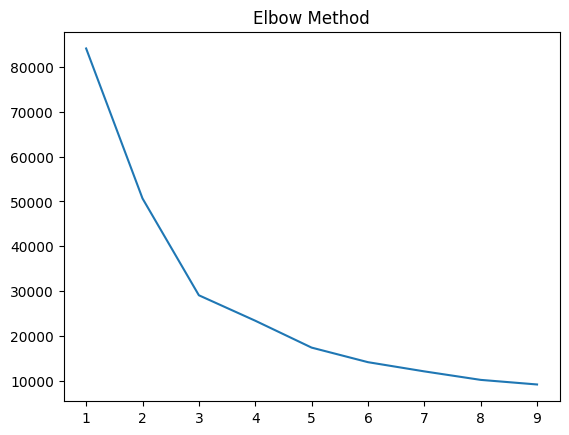

In [22]:
plt.plot(K, inertias)
plt.title('Elbow Method')
plt.show()

In [23]:
k_means_5 = KMeans(n_clusters=5, random_state=42)
labels_5 = k_means_5.fit_predict(X_pca)

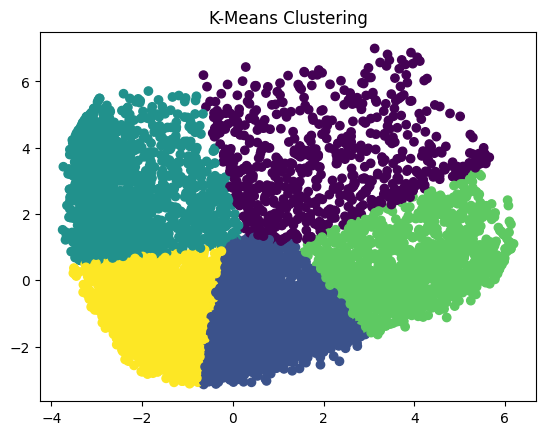

In [24]:
plt.scatter(x=X_pca[:, 0], y=X_pca[:, 1], c=labels_5)
plt.title('K-Means Clustering')
plt.show()

In [25]:
silhouette_score(X_pca, labels_5)

np.float64(0.3929476067261817)

In [26]:
sil_scores = []
K = range(2, 10)

for k in K:
    k_means = KMeans(n_clusters=k, random_state=42)
    labels = k_means.fit_predict(X_pca)
    sil_scores.append(silhouette_score(X_pca, labels))

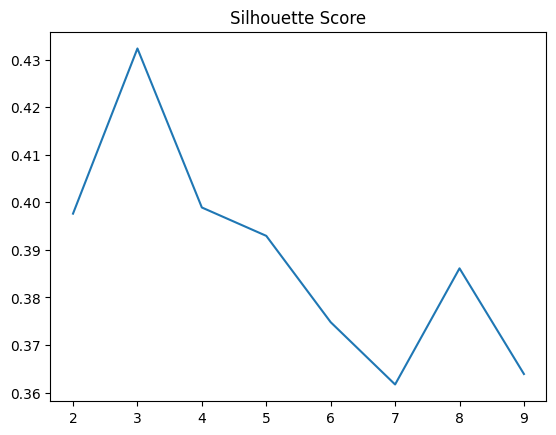

In [27]:
plt.plot(K, sil_scores)
plt.title('Silhouette Score')
plt.show()

In [28]:
k_means_final = KMeans(n_clusters=2, random_state=42)
labels_final = k_means_final.fit_predict(X_pca)

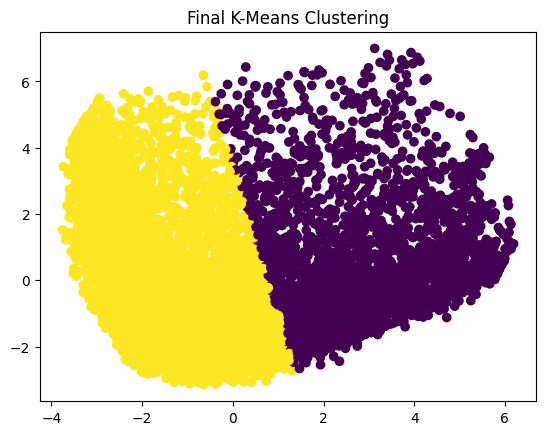

In [29]:
plt.scatter(x=X_pca[:, 0], y=X_pca[:, 1], c=labels_final)
plt.title('Final K-Means Clustering')
plt.show()

In [30]:
df_clean['Kategori_Cluster'] = labels_final

display(df_clean.head(10))

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Kategori_Cluster
0,40.900749,0.818182,95.4000,0.0000,95.40000,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,1
1,3202.467416,0.909091,0.0000,0.0000,0.00000,2784.552848,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,1
2,2495.148862,1.000000,773.1700,773.1700,0.00000,0.000000,1.000000,0.750000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,0
3,1666.670542,0.722223,1499.0000,1443.5125,0.00000,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12,1
4,817.714335,1.000000,16.0000,16.0000,0.00000,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,1
5,1809.828751,1.000000,1333.2800,0.0000,1171.59375,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,1715.497271,0.000000,12,0
6,627.260806,1.000000,2715.8725,1443.5125,688.38000,0.000000,1.000000,0.750000,1.000000,0.000000,0,41,13500.0,4177.921543,198.065894,0.357143,12,0
7,1823.652743,1.000000,436.2000,0.0000,436.20000,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12,1
8,1014.926473,1.000000,861.4900,661.4900,200.00000,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12,1
9,152.225975,0.722223,1281.6000,1281.6000,0.00000,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12,1


### Classification

In [31]:
df_clean['Kategori_Cluster'] = labels_final
display(df_clean.head(10))

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Kategori_Cluster
0,40.900749,0.818182,95.4000,0.0000,95.40000,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,1
1,3202.467416,0.909091,0.0000,0.0000,0.00000,2784.552848,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,1
2,2495.148862,1.000000,773.1700,773.1700,0.00000,0.000000,1.000000,0.750000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,0
3,1666.670542,0.722223,1499.0000,1443.5125,0.00000,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12,1
4,817.714335,1.000000,16.0000,16.0000,0.00000,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,1
5,1809.828751,1.000000,1333.2800,0.0000,1171.59375,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,1715.497271,0.000000,12,0
6,627.260806,1.000000,2715.8725,1443.5125,688.38000,0.000000,1.000000,0.750000,1.000000,0.000000,0,41,13500.0,4177.921543,198.065894,0.357143,12,0
7,1823.652743,1.000000,436.2000,0.0000,436.20000,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12,1
8,1014.926473,1.000000,861.4900,661.4900,200.00000,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12,1
9,152.225975,0.722223,1281.6000,1281.6000,0.00000,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12,1


In [32]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8950 non-null   float64
 1   BALANCE_FREQUENCY                 8950 non-null   float64
 2   PURCHASES                         8950 non-null   float64
 3   ONEOFF_PURCHASES                  8950 non-null   float64
 4   INSTALLMENTS_PURCHASES            8950 non-null   float64
 5   CASH_ADVANCE                      8950 non-null   float64
 6   PURCHASES_FREQUENCY               8950 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 10  CASH_ADVANCE_TRX                  8950 non-null   int64  
 11  PURCHASES_TRX                     8950 non-null   int64  
 12  CREDIT

In [33]:
X = df_clean.drop(columns='Kategori_Cluster')
y = df_clean['Kategori_Cluster']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [35]:
scaler2 = StandardScaler()
X_train = scaler2.fit_transform(X_train)
X_test = scaler2.transform(X_test)

## Logistic Regression

In [36]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

LogisticRegression()

In [37]:
y_pred_logreg = logreg.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_logreg)
conf_matrix = confusion_matrix(y_test, y_pred_logreg)
target_names = ['Class 0', 'Class 1']
class_report = classification_report(y_test, y_pred_logreg, target_names=target_names)

print(f"Accuracy Score: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")
print("Classification Report:")
print(class_report)

Accuracy Score: 0.9977653631284916
Confusion Matrix:
[[ 596    4]
 [   0 1190]]
Classification Report:
              precision    recall  f1-score   support

     Class 0       1.00      0.99      1.00       600
     Class 1       1.00      1.00      1.00      1190

    accuracy                           1.00      1790
   macro avg       1.00      1.00      1.00      1790
weighted avg       1.00      1.00      1.00      1790



In [38]:
param_grid_logreg = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

grid_search_logreg = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid_logreg,
    cv=5,
    scoring='accuracy'
)

grid_search_logreg.fit(X_train, y_train)

c:\PythonSGInstallation\envs\sg_env\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\PythonSGInstallation\envs\sg_env\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\PythonSGInstallation\envs\sg_env\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\PythonSGInstallation\envs\sg_env\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\PythonSGInstallation\envs\sg_env\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\PythonSGInstallation\envs\sg_env\Lib\site-packages\s

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'penalty': ['l1', 'l2'],
                         'solver': ['liblinear', 'saga']},
             scoring='accuracy')

In [39]:
y_pred_logreg = grid_search_logreg.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_logreg)
conf_matrix = confusion_matrix(y_test, y_pred_logreg)
class_report = classification_report(y_test, y_pred_logreg, target_names=target_names)

print(f"Accuracy Score: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")
print("Classification Report:")
print(class_report)

print("Parameter terbaik: ", grid_search_logreg.best_params_)
print("Skor akurasi terbaik: ", grid_search_logreg.best_score_)

Accuracy Score: 0.9994413407821229
Confusion Matrix:
[[ 600    0]
 [   1 1189]]
Classification Report:
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00       600
     Class 1       1.00      1.00      1.00      1190

    accuracy                           1.00      1790
   macro avg       1.00      1.00      1.00      1790
weighted avg       1.00      1.00      1.00      1790

Parameter terbaik:  {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Skor akurasi terbaik:  0.9990223463687151


## Naive Bayes

In [40]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

GaussianNB()

In [41]:
y_pred_gnb = gnb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_gnb)
conf_matrix = confusion_matrix(y_test, y_pred_gnb)
target_names = ['Class 0', 'Class 1']
class_report = classification_report(y_test, y_pred_gnb, target_names=target_names)

print(f"Accuracy Score: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")
print("Classification Report:")
print(class_report)

Accuracy Score: 0.9614525139664805
Confusion Matrix:
[[ 599    1]
 [  68 1122]]
Classification Report:
              precision    recall  f1-score   support

     Class 0       0.90      1.00      0.95       600
     Class 1       1.00      0.94      0.97      1190

    accuracy                           0.96      1790
   macro avg       0.95      0.97      0.96      1790
weighted avg       0.97      0.96      0.96      1790



In [42]:
param_grid_gnb = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

grid_search_gnb = GridSearchCV(
    estimator=gnb,
    param_grid=param_grid_gnb,
    cv=5,                 
    scoring='accuracy',   
    verbose=1,
    n_jobs=-1            
)

grid_search_gnb.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


GridSearchCV(cv=5, estimator=GaussianNB(), n_jobs=-1,
             param_grid={'var_smoothing': array([1.00000000e+00, 8.11130831e-01, 6.57933225e-01, 5.33669923e-01,
       4.32876128e-01, 3.51119173e-01, 2.84803587e-01, 2.31012970e-01,
       1.87381742e-01, 1.51991108e-01, 1.23284674e-01, 1.00000000e-01,
       8.11130831e-02, 6.57933225e-02, 5.33669923e-02, 4.32876128e-02,
       3.51119173e-02, 2.8480358...
       1.23284674e-07, 1.00000000e-07, 8.11130831e-08, 6.57933225e-08,
       5.33669923e-08, 4.32876128e-08, 3.51119173e-08, 2.84803587e-08,
       2.31012970e-08, 1.87381742e-08, 1.51991108e-08, 1.23284674e-08,
       1.00000000e-08, 8.11130831e-09, 6.57933225e-09, 5.33669923e-09,
       4.32876128e-09, 3.51119173e-09, 2.84803587e-09, 2.31012970e-09,
       1.87381742e-09, 1.51991108e-09, 1.23284674e-09, 1.00000000e-09])},
             scoring='accuracy', verbose=1)

In [43]:
y_pred_gnb = grid_search_gnb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_gnb)
conf_matrix = confusion_matrix(y_test, y_pred_gnb)
class_report = classification_report(y_test, y_pred_gnb, target_names=target_names)

print(f"Accuracy Score: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")
print("Classification Report:")
print(class_report)

print("Parameter terbaik: ", grid_search_gnb.best_params_)
print("Skor akurasi terbaik: ", grid_search_gnb.best_score_)

Accuracy Score: 0.9837988826815642
Confusion Matrix:
[[ 584   16]
 [  13 1177]]
Classification Report:
              precision    recall  f1-score   support

     Class 0       0.98      0.97      0.98       600
     Class 1       0.99      0.99      0.99      1190

    accuracy                           0.98      1790
   macro avg       0.98      0.98      0.98      1790
weighted avg       0.98      0.98      0.98      1790

Parameter terbaik:  {'var_smoothing': np.float64(0.3511191734215131)}
Skor akurasi terbaik:  0.9803072625698324


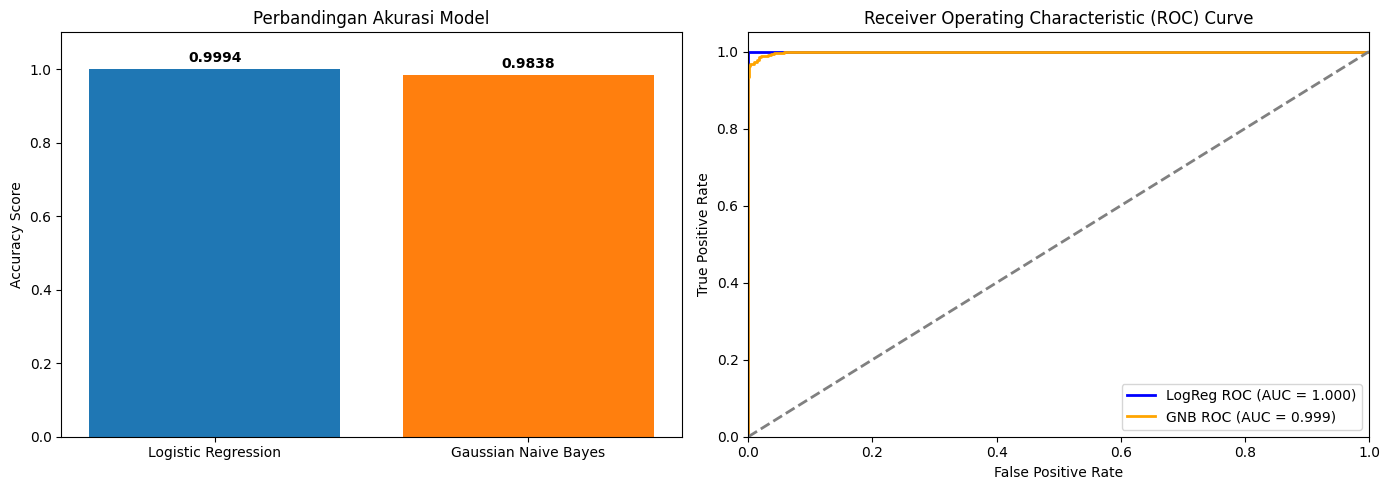

In [44]:
# Dapatkan probabilitas dan prediksi untuk kedua model
y_proba_logreg = grid_search_logreg.predict_proba(X_test)[:, 1]
y_proba_gnb = grid_search_gnb.predict_proba(X_test)[:, 1]

# Hitung Akurasi
acc_logreg = accuracy_score(y_test, y_pred_logreg)
acc_gnb = accuracy_score(y_test, y_pred_gnb)

# --- VISUALISASI 1: Bar Chart Akurasi ---
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

models = ['Logistic Regression', 'Gaussian Naive Bayes']
accuracies = [acc_logreg, acc_gnb]
colors = ['#1f77b4', '#ff7f0e']

ax[0].bar(models, accuracies, color=colors)
ax[0].set_ylim(0, 1.1)
ax[0].set_title('Perbandingan Akurasi Model')
ax[0].set_ylabel('Accuracy Score')
for i, v in enumerate(accuracies):
    ax[0].text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

# --- VISUALISASI 2: Kurva ROC ---
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_logreg)
roc_auc_log = auc(fpr_log, tpr_log)

fpr_gnb, tpr_gnb, _ = roc_curve(y_test, y_proba_gnb)
roc_auc_gnb = auc(fpr_gnb, tpr_gnb)

ax[1].plot(fpr_log, tpr_log, color='blue', lw=2, label=f'LogReg ROC (AUC = {roc_auc_log:.3f})')
ax[1].plot(fpr_gnb, tpr_gnb, color='orange', lw=2, label=f'GNB ROC (AUC = {roc_auc_gnb:.3f})')
ax[1].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('Receiver Operating Characteristic (ROC) Curve')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# DEPLOYMENT

In [45]:
joblib.dump(scaler2, 'scaler.pkl')
joblib.dump(grid_search_logreg.best_estimator_, 'logreg_model.pkl')
joblib.dump(grid_search_gnb.best_estimator_, 'gnb_model.pkl')

['gnb_model.pkl']

In [46]:
!ngrok config add-authtoken 3DvfEyCRS93bTrynmSXMBTzZV0r_7SHRKTcgG8ukVvhRUW34i

Authtoken saved to configuration file: C:\Users\kevin\AppData\Local\ngrok\ngrok.yml


In [47]:
%%writefile app.py

from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc
)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')


# ─────────────────────────────────────────
# PAGE CONFIG
# ─────────────────────────────────────────
st.set_page_config(
    page_title="CreditCard.AI – Kelompok 6",
    page_icon="💳",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ─────────────────────────────────────────
# GLOBAL STYLE
# ─────────────────────────────────────────
st.markdown("""
<style>
    /* Sidebar background */
    [data-testid="stSidebar"] {
        background: linear-gradient(180deg, #1a237e 0%, #283593 50%, #1565c0 100%);
    }
    [data-testid="stSidebar"] * {
        color: #ffffff !important;
    }
    /* Sidebar radio buttons */
    [data-testid="stSidebar"] .stRadio > div { gap: 4px !important; }
    [data-testid="stSidebar"] .stRadio label {
        background: rgba(255,255,255,0.06) !important;
        border: 1px solid rgba(255,255,255,0.1) !important;
        border-radius: 10px !important;
        padding: 10px 14px !important;
        margin-bottom: 4px !important;
        display: flex !important;
        align-items: center !important;
        cursor: pointer !important;
        transition: all 0.2s ease !important;
        font-size: 0.92rem !important;
        font-weight: 500 !important;
    }
    [data-testid="stSidebar"] .stRadio label:hover {
        background: rgba(255,255,255,0.15) !important;
        border-color: rgba(255,255,255,0.25) !important;
    }
    /* Section header */
    .section-header {
        background: linear-gradient(135deg, #1a237e, #1565c0);
        color: white !important;
        padding: 12px 20px;
        border-radius: 10px;
        margin-bottom: 16px;
    }
    /* Metric cards */
    .metric-card {
        background: linear-gradient(135deg, #e3f2fd, #bbdefb);
        border-left: 5px solid #1565c0;
        border-radius: 10px;
        padding: 16px 20px;
        margin-bottom: 12px;
    }
    /* Cluster card */
    .cluster-card-0 {
        background: linear-gradient(135deg, #e8f5e9, #c8e6c9);
        border-left: 5px solid #2e7d32;
        border-radius: 10px;
        padding: 16px 20px;
        margin-bottom: 12px;
    }
    .cluster-card-1 {
        background: linear-gradient(135deg, #fce4ec, #f8bbd0);
        border-left: 5px solid #c62828;
        border-radius: 10px;
        padding: 16px 20px;
        margin-bottom: 12px;
    }
    /* Tujuan analisis columns separator */
    .tujuan-col {
        border-right: 1px solid #e0e0e0;
        padding-right: 16px;
    }
    hr { margin: 8px 0; }
</style>
""", unsafe_allow_html=True)


# ─────────────────────────────────────────
# CACHED DATA & MODELS
# ─────────────────────────────────────────
@st.cache_data
def load_data():
    df = pd.read_csv('CC GENERAL.csv')
    return df


@st.cache_data
def prepare_data(_df):
    df_clean = _df.drop(columns=['CUST_ID']).copy()
    df_clean['MINIMUM_PAYMENTS'] = df_clean['MINIMUM_PAYMENTS'].fillna(
        df_clean['MINIMUM_PAYMENTS'].median())
    df_clean['CREDIT_LIMIT'] = df_clean['CREDIT_LIMIT'].fillna(
        df_clean['CREDIT_LIMIT'].median())
    # IQR Capping
    for col in df_clean.columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        df_clean[col] = df_clean[col].clip(
            lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)
    return df_clean


@st.cache_data
def run_clustering(_df_clean):
    scaler = StandardScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(
        _df_clean), columns=_df_clean.columns)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(df_scaled)

    # 5-cluster (eksplorasi awal)
    km5 = KMeans(n_clusters=5, random_state=42, n_init=10)
    labels_5 = km5.fit_predict(X_pca)

    # Elbow + Silhouette
    inertias, sil_scores, k_range = [], [], range(2, 11)
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        lbl = km.fit_predict(X_pca)
        inertias.append(km.inertia_)
        from sklearn.metrics import silhouette_score
        sil_scores.append(silhouette_score(X_pca, lbl))

    # Final 2-cluster
    km2 = KMeans(n_clusters=2, random_state=42, n_init=10)
    labels_2 = km2.fit_predict(X_pca)

    return X_pca, labels_5, labels_2, list(k_range), inertias, sil_scores


@st.cache_data
def run_models(_df_clean):
    scaler2 = joblib.load('scaler.pkl')
    df_scaled = pd.DataFrame(scaler2.transform(
        _df_clean), columns=_df_clean.columns)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(df_scaled)
    km2 = KMeans(n_clusters=2, random_state=42, n_init=10)
    labels_2 = km2.fit_predict(X_pca)

    df_model = _df_clean.copy()
    df_model['Cluster'] = labels_2

    X = df_model.drop(columns='Cluster')
    y = df_model['Cluster']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)

    X_train_sc = scaler2.transform(X_train)
    X_test_sc = scaler2.transform(X_test)

    # GridSearchCV Logistic Regression
    param_grid_lr = {
        'C':       [0.01, 0.1, 1, 10],
        'solver':  ['lbfgs', 'liblinear'],
        'max_iter': [200, 500]
    }
    gs_lr = GridSearchCV(LogisticRegression(), param_grid_lr,
                         cv=5, scoring='accuracy', n_jobs=-1)
    gs_lr.fit(X_train_sc, y_train)

    # GridSearchCV Naive Bayes
    param_grid_gnb = {'var_smoothing': np.logspace(-12, -1, 20)}
    gs_gnb = GridSearchCV(GaussianNB(), param_grid_gnb,
                          cv=5, scoring='accuracy', n_jobs=-1)
    gs_gnb.fit(X_train_sc, y_train)

    y_pred_lr = gs_lr.predict(X_test_sc)
    y_pred_gnb = gs_gnb.predict(X_test_sc)

    y_proba_lr = gs_lr.predict_proba(X_test_sc)[:, 1]
    y_proba_gnb = gs_gnb.predict_proba(X_test_sc)[:, 1]

    acc_lr = accuracy_score(y_test, y_pred_lr)
    acc_gnb = accuracy_score(y_test, y_pred_gnb)

    fpr_lr,  tpr_lr,  _ = roc_curve(y_test, y_proba_lr)
    fpr_gnb, tpr_gnb, _ = roc_curve(y_test, y_proba_gnb)
    auc_lr = auc(fpr_lr,  tpr_lr)
    auc_gnb = auc(fpr_gnb, tpr_gnb)

    cm_lr = confusion_matrix(y_test, y_pred_lr)
    cm_gnb = confusion_matrix(y_test, y_pred_gnb)

    cr_lr = classification_report(y_test, y_pred_lr,  target_names=[
                                  'Cluster 0', 'Cluster 1'], output_dict=True)
    cr_gnb = classification_report(y_test, y_pred_gnb, target_names=[
                                   'Cluster 0', 'Cluster 1'], output_dict=True)

    return {
        'best_params_lr':  gs_lr.best_params_,
        'best_params_gnb': gs_gnb.best_params_,
        'acc_lr':  acc_lr,  'acc_gnb':  acc_gnb,
        'fpr_lr':  fpr_lr,  'tpr_lr':   tpr_lr,  'auc_lr':  auc_lr,
        'fpr_gnb': fpr_gnb, 'tpr_gnb':  tpr_gnb, 'auc_gnb': auc_gnb,
        'cm_lr':   cm_lr,   'cm_gnb':   cm_gnb,
        'cr_lr':   cr_lr,   'cr_gnb':   cr_gnb,
    }


# ─────────────────────────────────────────
# SESSION STATE – active menu
# ─────────────────────────────────────────
if "active_menu" not in st.session_state:
    st.session_state.active_menu = "Homepage"

MENUS = [
    ("Homepage",           "🏠", "Homepage"),
    ("EDA & Preparation",  "📊", "EDA & Preparation"),
    ("Clustering",         "🔵", "Clustering"),
    ("Perbandingan Model", "📈", "Perbandingan Model"),
    ("Simulasi Prediksi",  "🤖", "Simulasi Prediksi"),
]

# ─────────────────────────────────────────
# SIDEBAR
# ─────────────────────────────────────────
with st.sidebar:
    st.markdown("""
    <div style="padding:24px 8px 12px 8px;text-align:center;">
        <div style="font-size:2.4rem;">💳</div>
        <div style="font-size:1.2rem;font-weight:800;letter-spacing:1px;color:white;">CreditCard.AI</div>
        <div style="font-size:0.72rem;color:rgba(255,255,255,0.6);margin-top:2px;">Kelompok 6 · SI4802</div>
    </div>
    <div style="height:1px;background:rgba(255,255,255,0.2);margin:0 0 14px 0;"></div>
    <div style="font-size:0.68rem;font-weight:700;letter-spacing:2.5px;color:rgba(255,255,255,0.45);
                padding:0 6px;margin-bottom:10px;">NAVIGASI</div>
    """, unsafe_allow_html=True)

    for key, icon, label in MENUS:
        is_active = st.session_state.active_menu == key
        btn_style = (
            "background:rgba(255,255,255,0.92);color:#1a237e !important;"
            "font-weight:700;border:2px solid rgba(255,255,255,0.95);"
            "transform:scale(1.02);box-shadow:0 4px 14px rgba(0,0,0,0.25);"
        ) if is_active else (
            "background:rgba(255,255,255,0.07);color:rgba(255,255,255,0.9) !important;"
            "font-weight:500;border:1px solid rgba(255,255,255,0.15);"
        )
        st.markdown(f"""
        <div style="margin-bottom:6px;">
            <form action="" method="get">
                <button name="nav" value="{key}" type="submit" style="
                    width:100%;text-align:left;padding:11px 14px;
                    border-radius:10px;cursor:pointer;
                    font-size:0.9rem;transition:all 0.18s ease;
                    {btn_style}">
                    {icon}&nbsp;&nbsp;{label}
                </button>
            </form>
        </div>
        """, unsafe_allow_html=True)
        if st.button(f"{icon}  {label}", key=f"nav_{key}", use_container_width=True,
                     type="primary" if is_active else "secondary"):
            st.session_state.active_menu = key
            st.rerun()

    st.markdown("""
    <div style="height:1px;background:rgba(255,255,255,0.2);margin:14px 0 10px 0;"></div>
    <div style="font-size:0.68rem;color:rgba(255,255,255,0.4);text-align:center;">
        Data Mining · SI4802<br>Kelompok 6 · 2026
    </div>
    """, unsafe_allow_html=True)

# ── hide default streamlit button styles, keep only our sidebar buttons custom ──
st.markdown("""
<style>
[data-testid="stSidebar"] .stButton button {
    width: 100% !important;
    text-align: left !important;
    padding: 11px 16px !important;
    border-radius: 10px !important;
    font-size: 0.9rem !important;
    transition: all 0.18s ease !important;
    border: 1px solid rgba(255,255,255,0.15) !important;
    background: rgba(255,255,255,0.07) !important;
    color: rgba(255,255,255,0.9) !important;
    font-weight: 500 !important;
    box-shadow: none !important;
    margin-bottom: 0 !important;
}
[data-testid="stSidebar"] .stButton button:hover {
    background: rgba(255,255,255,0.16) !important;
    border-color: rgba(255,255,255,0.3) !important;
    transform: translateX(3px) !important;
}
[data-testid="stSidebar"] .stButton button[kind="primary"] {
    background: rgba(255,255,255,0.92) !important;
    color: #1a237e !important;
    font-weight: 700 !important;
    border: 2px solid white !important;
    box-shadow: 0 4px 14px rgba(0,0,0,0.2) !important;
    transform: scale(1.02) !important;
}
/* hide the HTML form buttons — only real st.button used */
[data-testid="stSidebar"] form { display: none !important; }
</style>
""", unsafe_allow_html=True)

menu = st.session_state.active_menu


# ═══════════════════════════════════════════
# MENU 1 – HOMEPAGE
# ═══════════════════════════════════════════
if menu == "Homepage":
    df = load_data()
    st.image("Header_Web.webp", use_container_width=True)
    st.markdown("<br>", unsafe_allow_html=True)

    # ── Identitas Kelompok ──
    st.markdown('<div class="section-header"><h3 style="margin:0;color:white">👥 Identitas Kelompok</h3></div>',
                unsafe_allow_html=True)
    col1, col2 = st.columns([1, 2])
    with col1:
        st.markdown("""
        **Mata Kuliah:** Data Mining  
        **Kelas:** SI4802  
        **Kelompok:** 6
        """)
    with col2:
        st.markdown("""
        Muhammad Daffa Izzati &nbsp;·&nbsp; 102022430036  
        Muhammad Daffa Reifansya &nbsp;·&nbsp; 102022400329  
        Kevin Muhammad Althaf &nbsp;·&nbsp; 102022400325  
        Sekar Erliana Putri &nbsp;·&nbsp; 102022430069
        """)

    st.divider()

    # ── Alasan Pemilihan Dataset ──
    st.markdown('<div class="section-header"><h3 style="margin:0;color:white">💡 Mengapa Dataset Ini?</h3></div>',
                unsafe_allow_html=True)
    st.markdown("""
    Dataset **CC GENERAL** berisi data perilaku transaksi **8.950 nasabah** kartu kredit selama 6 bulan terakhir.
    Kami memilih dataset ini karena:
    - Relevan dengan industri keuangan perbankan yang terus berkembang.
    - Memiliki variasi fitur yang kaya sehingga cocok untuk eksplorasi clustering dan klasifikasi.
    - Dapat digunakan untuk membantu bank memahami segmentasi nasabah secara otomatis dan data-driven.
    - Ukuran dataset yang cukup besar (~9K baris, 18 kolom) memberikan hasil analisis yang lebih robust.
    """)

    st.divider()

    # ── Tujuan Analisis ──
    st.markdown('<div class="section-header"><h3 style="margin:0;color:white">🎯 Tujuan Analisis</h3></div>',
                unsafe_allow_html=True)
    row1_c1, row1_c2 = st.columns(2)
    with row1_c1:
        with st.container(border=True):
            st.markdown("**1. Segmentasi Nasabah**")
            st.markdown(
                "Mengelompokkan nasabah berdasarkan pola transaksi menggunakan algoritma K-Means Clustering.")
    with row1_c2:
        with st.container(border=True):
            st.markdown("**2. Pemahaman Perilaku**")
            st.markdown(
                "Memahami karakteristik tiap segmen nasabah — apakah cenderung berbelanja atau menarik uang tunai.")
    row2_c1, row2_c2 = st.columns(2)
    with row2_c1:
        with st.container(border=True):
            st.markdown("**3. Perbandingan Model**")
            st.markdown(
                "Membandingkan performa Logistic Regression dan Gaussian Naive Bayes untuk klasifikasi segmen nasabah.")
    with row2_c2:
        with st.container(border=True):
            st.markdown("**4. Simulasi Prediksi**")
            st.markdown(
                "Membangun sistem simulasi interaktif yang dapat memprediksi segmen nasabah baru berdasarkan data inputan.")

    st.divider()

    # ── Penjelasan Variabel ──
    st.markdown('<div class="section-header"><h3 style="margin:0;color:white">📌 Penjelasan Variabel Dataset</h3></div>', unsafe_allow_html=True)
    st.markdown(
        f"Dataset memiliki **{df.shape[0]:,} baris** dan **{df.shape[1]} kolom**, dikelompokkan menjadi 4 kategori variabel berikut.")
    st.markdown("<br>", unsafe_allow_html=True)

    # ── Baris 1: Saldo & Pembelian (full width) ──
    with st.container(border=True):
        st.markdown("##### 💰 Saldo & Pembelian")
        st.markdown("---")
        var_list_1 = [
            ("BALANCE",
             "Sisa saldo kartu kredit nasabah pada periode observasi."),
            ("BALANCE_FREQUENCY",
             "Seberapa sering saldo diperbarui (skala 0–1; semakin mendekati 1 = semakin sering)."),
            ("PURCHASES",
             "Total nilai pembelian yang dilakukan nasabah selama periode berjalan."),
            ("ONEOFF_PURCHASES",
             "Nilai pembelian yang dibayar sekali lunas, bukan cicilan."),
            ("INSTALLMENTS_PURCHASES",
             "Nilai pembelian yang dibayar secara cicilan/angsuran."),
            ("PURCHASES_FREQUENCY",
             "Frekuensi nasabah melakukan pembelian (skala 0–1)."),
            ("ONEOFF_PURCHASES_FREQUENCY",
             "Frekuensi pembelian sekali bayar (skala 0–1)."),
            ("PURCHASES_INSTALLMENTS_FREQUENCY",
             "Frekuensi pembelian cicilan (skala 0–1)."),
            ("PURCHASES_TRX",
             "Jumlah total transaksi pembelian yang tercatat."),
        ]
        # Tampilkan dalam 3 kolom agar tidak terlalu panjang ke bawah
        col_v1, col_v2, col_v3 = st.columns(3)
        for i, (name, desc) in enumerate(var_list_1):
            target = [col_v1, col_v2, col_v3][i % 3]
            with target:
                st.markdown(f"**`{name}`**  \n{desc}")

    st.markdown("<br>", unsafe_allow_html=True)

    # ── Baris 2: Penarikan Tunai | Identitas ──
    vg2, vg4 = st.columns(2)
    with vg2:
        with st.container(border=True):
            st.markdown("##### 🏧 Penarikan Tunai")
            st.markdown("---")
            var_list_2 = [
                ("CASH_ADVANCE",
                 "Total uang tunai yang ditarik nasabah menggunakan kartu kredit."),
                ("CASH_ADVANCE_FREQUENCY",
                 "Seberapa sering nasabah melakukan penarikan tunai (skala 0–1)."),
                ("CASH_ADVANCE_TRX",
                 "Jumlah transaksi penarikan uang tunai yang dilakukan."),
            ]
            for name, desc in var_list_2:
                st.markdown(f"**`{name}`**  \n{desc}")

    with vg4:
        with st.container(border=True):
            st.markdown("##### 🪪 Identitas")
            st.markdown("---")
            var_list_4 = [
                ("CUST_ID", "ID unik setiap nasabah. Bersifat kategorik dan tidak digunakan dalam proses pemodelan."),
                ("TENURE",  "Lama nasabah menggunakan layanan kartu kredit, dalam satuan bulan."),
            ]
            for name, desc in var_list_4:
                st.markdown(f"**`{name}`**  \n{desc}")

    st.markdown("<br>", unsafe_allow_html=True)

    # ── Baris 3: Kredit & Pembayaran (full width) ──
    with st.container(border=True):
        st.markdown("##### 💳 Kredit & Pembayaran")
        st.markdown("---")
        var_list_3 = [
            ("CREDIT_LIMIT",     "Batas maksimum kredit yang diberikan bank kepada nasabah."),
            ("PAYMENTS",         "Total pembayaran tagihan yang dilakukan nasabah."),
            ("MINIMUM_PAYMENTS",
             "Jumlah pembayaran minimum yang dilakukan (jika tidak melunasi penuh)."),
            ("PRC_FULL_PAYMENT",
             "Proporsi bulan di mana nasabah membayar tagihan secara penuh (skala 0–1)."),
        ]
        col_w1, col_w2 = st.columns(2)
        for i, (name, desc) in enumerate(var_list_3):
            target = col_w1 if i % 2 == 0 else col_w2
            with target:
                st.markdown(f"**`{name}`**  \n{desc}")


# ═══════════════════════════════════════════
# MENU 2 – EDA & PREPARATION
# ═══════════════════════════════════════════
elif menu == "EDA & Preparation":
    df = load_data()
    df_clean = prepare_data(df)
    st.markdown('<div class="section-header"><h2 style="margin:0;color:white">📊 Exploratory Data Analysis & Data Preparation</h2></div>', unsafe_allow_html=True)

    tab_raw, tab_stats, tab_missing, tab_outlier, tab_hist, tab_corr = st.tabs([
        "📁 Raw Data", "📐 Statistik Deskriptif", "🔍 Missing Values",
        "📦 Outlier Handling", "📊 Distribusi Fitur", "🌡️ Korelasi"
    ])

    # ── Raw Data ──
    with tab_raw:
        st.subheader("Preview Dataset Asli")
        st.dataframe(df.head(10), use_container_width=True)
        c1, c2, c3 = st.columns(3)
        c1.metric("Jumlah Baris", f"{df.shape[0]:,}")
        c2.metric("Jumlah Kolom", f"{df.shape[1]}")
        c3.metric("Duplikat", f"{df.duplicated().sum()}")

    # ── Statistik Deskriptif ──
    with tab_stats:
        st.subheader("Statistik Deskriptif")
        st.dataframe(df.describe().T.style.format(
            "{:.3f}"), use_container_width=True)

    # ── Missing Values ──
    with tab_missing:
        st.subheader("Pengecekan Missing Values")
        missing = df.isnull().sum()
        missing_pct = (missing / len(df) * 100).round(2)
        df_missing = pd.DataFrame({
            'Jumlah Missing': missing,
            'Persentase (%)': missing_pct
        })
        df_missing = df_missing[df_missing['Jumlah Missing'] > 0]
        if df_missing.empty:
            st.success("Tidak ada missing value pada dataset!")
        else:
            st.dataframe(df_missing, use_container_width=True)
            st.markdown("""
            **Penanganan Missing Values:**
            - `MINIMUM_PAYMENTS` → diisi dengan **median** (robust terhadap outlier)
            - `CREDIT_LIMIT` → diisi dengan **median** (robust terhadap outlier)
            """)
            fig_mv, ax_mv = plt.subplots(figsize=(6, 3))
            ax_mv.barh(df_missing.index,
                       df_missing['Jumlah Missing'], color='#1565c0')
            ax_mv.set_xlabel('Jumlah Missing')
            ax_mv.set_title('Missing Values per Kolom')
            plt.tight_layout()
            st.pyplot(fig_mv)

    # ── Outlier Handling ──
    with tab_outlier:
        st.subheader("Outlier Handling dengan IQR Capping")
        st.markdown("""
        Outlier ditangani menggunakan metode **IQR Capping** — nilai di luar batas `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]`
        di-clip ke batas tersebut tanpa menghapus data. Berikut perbandingan **sebelum** dan **sesudah** capping untuk semua fitur:
        """)

        cols_num = df_clean.columns.tolist()
        n_cols = 3
        n_rows = (len(cols_num) + n_cols - 1) // n_cols

        fig_bp, axes_bp = plt.subplots(
            n_rows, n_cols * 2, figsize=(22, n_rows * 3.2))
        axes_bp = axes_bp.reshape(n_rows, n_cols * 2)

        for idx, col in enumerate(cols_num):
            row = idx // n_cols
            col_pair_start = (idx % n_cols) * 2

            ax_before = axes_bp[row, col_pair_start]
            ax_after = axes_bp[row, col_pair_start + 1]

            raw_col = df[col].dropna()
            Q1 = raw_col.quantile(0.25)
            Q3 = raw_col.quantile(0.75)
            IQR = Q3 - Q1
            n_out = ((raw_col < Q1 - 1.5*IQR) | (raw_col > Q3 + 1.5*IQR)).sum()

            ax_before.boxplot(raw_col, patch_artist=True,
                              boxprops=dict(facecolor='#ffcdd2'),
                              medianprops=dict(color='#c62828', linewidth=2),
                              whiskerprops=dict(color='#c62828'),
                              capprops=dict(color='#c62828'),
                              flierprops=dict(marker='o', markerfacecolor='#ef9a9a', markersize=2))
            ax_before.set_title(f'{col}\nSebelum ({n_out} outlier)',
                                fontsize=7.5, fontweight='bold', color='#c62828')
            ax_before.tick_params(labelsize=6)

            ax_after.boxplot(df_clean[col], patch_artist=True,
                             boxprops=dict(facecolor='#c8e6c9'),
                             medianprops=dict(color='#2e7d32', linewidth=2),
                             whiskerprops=dict(color='#2e7d32'),
                             capprops=dict(color='#2e7d32'))
            ax_after.set_title(f'{col}\nSetelah (0 outlier)',
                               fontsize=7.5, fontweight='bold', color='#2e7d32')
            ax_after.tick_params(labelsize=6)

        # Sembunyikan subplot kosong
        for idx in range(len(cols_num), n_rows * n_cols):
            row = idx // n_cols
            col_pair_start = (idx % n_cols) * 2
            fig_bp.delaxes(axes_bp[row, col_pair_start])
            fig_bp.delaxes(axes_bp[row, col_pair_start + 1])

        plt.suptitle('Perbandingan Boxplot Sebelum & Sesudah IQR Capping',
                     fontsize=13, fontweight='bold', y=1.01)
        plt.tight_layout()
        st.pyplot(fig_bp)

    # ── Distribusi Histogram ──
    with tab_hist:
        st.subheader("Distribusi Setiap Fitur (Histogram)")
        fig_hist, axes_hist = plt.subplots(4, 5, figsize=(20, 14))
        axes_hist = axes_hist.flatten()
        cols = df_clean.columns.tolist()
        for i, col in enumerate(cols):
            axes_hist[i].hist(df_clean[col], bins=30,
                              color='#1565c0', edgecolor='white', alpha=0.85)
            axes_hist[i].set_title(col, fontsize=9, fontweight='bold')
            axes_hist[i].set_xlabel('')
            axes_hist[i].tick_params(labelsize=7)
        # Sembunyikan subplot kosong
        for j in range(len(cols), len(axes_hist)):
            fig_hist.delaxes(axes_hist[j])
        plt.suptitle('Distribusi Semua Fitur (Setelah Preprocessing)',
                     fontsize=14, fontweight='bold', y=1.01)
        plt.tight_layout()
        st.pyplot(fig_hist)

    # ── Heatmap Korelasi ──
    with tab_corr:
        st.subheader("Heatmap Korelasi Antar Fitur")
        fig_corr, ax_corr = plt.subplots(figsize=(14, 10))
        corr_matrix = df_clean.corr()
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        sns.heatmap(
            corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='Blues', ax=ax_corr, linewidths=0.5,
            annot_kws={'size': 7}
        )
        ax_corr.set_title('Correlation Heatmap (Lower Triangle)',
                          fontsize=13, fontweight='bold')
        plt.tight_layout()
        st.pyplot(fig_corr)


# ═══════════════════════════════════════════
# MENU 3 – CLUSTERING
# ═══════════════════════════════════════════
elif menu == "Clustering":
    df = load_data()
    df_clean = prepare_data(df)
    st.markdown('<div class="section-header"><h2 style="margin:0;color:white">🔵 K-Means Clustering – Segmentasi Nasabah</h2></div>', unsafe_allow_html=True)

    with st.spinner("Menjalankan proses clustering... ⏳"):
        X_pca, labels_5, labels_2, k_range, inertias, sil_scores = run_clustering(
            df_clean)

    tab_5, tab_eval, tab_final = st.tabs([
        "🔬 Eksplorasi Awal (5 Cluster)",
        "📉 Evaluasi Jumlah Cluster",
        "✅ Hasil Final (2 Cluster)"
    ])

    # ── Eksplorasi 5 Cluster ──
    with tab_5:
        st.subheader("Percobaan Awal: 5 Cluster")
        st.markdown("""
        Pada tahap awal, kami mencoba membagi data menjadi **5 cluster** untuk melihat sebaran awal nasabah
        dalam ruang fitur yang telah direduksi dengan PCA menjadi 2 dimensi.
        """)
        fig5, ax5 = plt.subplots(figsize=(9, 5))
        scatter = ax5.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_5,
                              cmap='tab10', s=15, alpha=0.6)
        plt.colorbar(scatter, ax=ax5, label='Cluster')
        ax5.set_title('K-Means Clustering dengan 5 Cluster (PCA 2D)',
                      fontsize=13, fontweight='bold')
        ax5.set_xlabel('Principal Component 1')
        ax5.set_ylabel('Principal Component 2')
        plt.tight_layout()
        st.pyplot(fig5)

        st.markdown("""
        <p style="font-size:1.05rem; line-height:1.8; margin-top:16px;">
        Dengan 5 cluster, beberapa kelompok tampak <strong>berdekatan dan saling tumpang tindih</strong> satu sama lain.
        Hal ini menunjukkan bahwa pembagian menjadi 5 kelompok terlalu granular dan kurang bermakna secara bisnis.
        Oleh karena itu, perlu dilakukan evaluasi lebih lanjut menggunakan <strong>Elbow Method</strong> dan
        <strong>Silhouette Score</strong> untuk menentukan jumlah cluster yang benar-benar optimal.
        </p>
        """, unsafe_allow_html=True)

    # ── Evaluasi ──
    with tab_eval:
        st.subheader("Mencari Jumlah Cluster Optimal")
        col_e1, col_e2 = st.columns(2)

        with col_e1:
            fig_elbow, ax_elbow = plt.subplots(figsize=(6, 4))
            ax_elbow.plot(k_range, inertias, 'bo-', linewidth=2,
                          markersize=7, color='#1565c0')
            ax_elbow.axvline(x=2, color='red', linestyle='--',
                             linewidth=1.5, label='k=2 (dipilih)')
            ax_elbow.set_xlabel('Jumlah Cluster (k)')
            ax_elbow.set_ylabel('Inertia (Within-cluster SSE)')
            ax_elbow.set_title('Elbow Method', fontsize=12, fontweight='bold')
            ax_elbow.legend()
            ax_elbow.grid(alpha=0.3)
            plt.tight_layout()
            st.pyplot(fig_elbow)

        with col_e2:
            fig_sil, ax_sil = plt.subplots(figsize=(6, 4))
            ax_sil.plot(k_range, sil_scores, 's-', linewidth=2,
                        markersize=7, color='#2e7d32')
            ax_sil.axvline(x=2, color='red', linestyle='--',
                           linewidth=1.5, label='k=2 (dipilih)')
            ax_sil.set_xlabel('Jumlah Cluster (k)')
            ax_sil.set_ylabel('Silhouette Score')
            ax_sil.set_title('Silhouette Score',
                             fontsize=12, fontweight='bold')
            ax_sil.legend()
            ax_sil.grid(alpha=0.3)
            plt.tight_layout()
            st.pyplot(fig_sil)

        # Tabel Skor — highlight hanya baris k=2
        df_eval = pd.DataFrame(
            {'k': k_range, 'Inertia': inertias, 'Silhouette Score': sil_scores})
        df_eval = df_eval.set_index('k')

        def highlight_k2(row):
            return ['background-color: #fff9c4; font-weight: bold'] * len(row) if row.name == 2 else [''] * len(row)

        st.dataframe(
            df_eval.style.apply(highlight_k2, axis=1).format('{:.4f}'),
            use_container_width=True
        )
        st.caption(
            "🟡 Baris yang di-highlight menunjukkan k=2 yang dipilih sebagai jumlah cluster optimal.")

        st.success("**Kesimpulan:** Berdasarkan Elbow Method dan Silhouette Score, nilai **k=2** dipilih sebagai jumlah cluster optimal karena memberikan pemisahan antar kelompok yang paling jelas dan bermakna secara bisnis.")

    # ── Hasil Final 2 Cluster ──
    with tab_final:
        st.subheader("Hasil Akhir: 2 Cluster Nasabah")

        fig2, ax2 = plt.subplots(figsize=(9, 5))
        colors_2 = ['#1565c0', '#c62828']
        for cl, color in zip([0, 1], colors_2):
            mask = labels_2 == cl
            ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                        c=color, s=15, alpha=0.6, label=f'Cluster {cl}')
        ax2.set_title('K-Means Clustering – 2 Cluster Final (PCA 2D)',
                      fontsize=13, fontweight='bold')
        ax2.set_xlabel('Principal Component 1')
        ax2.set_ylabel('Principal Component 2')
        ax2.legend(fontsize=11)
        ax2.grid(alpha=0.2)
        plt.tight_layout()
        st.pyplot(fig2)

        # Distribusi cluster
        unique, counts = np.unique(labels_2, return_counts=True)
        st.markdown("**Distribusi Nasabah per Cluster:**")
        cc1, cc2 = st.columns(2)
        cc1.metric("Cluster 0 – Active Shoppers 🛒",
                   f"{counts[0]:,} nasabah", f"{counts[0]/len(labels_2)*100:.1f}%")
        cc2.metric("Cluster 1 – Cash Advance Users 🏧",
                   f"{counts[1]:,} nasabah", f"{counts[1]/len(labels_2)*100:.1f}%")

        st.markdown("<br>", unsafe_allow_html=True)
        col_cl1, col_cl2 = st.columns(2)

        with col_cl1:
            st.markdown("""
            <div style="background:#dbeafe; border-left:6px solid #1565c0; border-radius:10px; padding:18px 22px; margin-bottom:12px;">
                <h4 style="color:#000000; margin-top:0;">🛒 Cluster 0 – Active Shoppers</h4>
                <b style="color:#000000;">Karakteristik Utama:</b>
                <ul style="color:#000000;">
                    <li>Sering melakukan transaksi pembelian langsung dengan kartu kredit</li>
                    <li>Frekuensi pembelian (one-off maupun cicilan) yang tinggi</li>
                    <li>Sangat jarang melakukan penarikan uang tunai (cash advance)</li>
                    <li>Cenderung memiliki jumlah transaksi pembelian yang banyak</li>
                    <li>Memanfaatkan kartu kredit sebagai alat belanja utama</li>
                </ul>
                <b style="color:#000000;">Rekomendasi Bank:</b> <span style="color:#000000;">Tawarkan program cashback, reward poin, dan promosi merchant.</span>
            </div>
            """, unsafe_allow_html=True)

        with col_cl2:
            st.markdown("""
            <div style="background:#fee2e2; border-left:6px solid #c62828; border-radius:10px; padding:18px 22px; margin-bottom:12px;">
                <h4 style="color:#000000; margin-top:0;">🏧 Cluster 1 – Cash Advance Users</h4>
                <b style="color:#000000;">Karakteristik Utama:</b>
                <ul style="color:#000000;">
                    <li>Jarang melakukan pembelian menggunakan kartu kredit</li>
                    <li>Sering menggunakan kartu kredit untuk menarik uang tunai</li>
                    <li>Frekuensi cash advance yang tinggi dengan jumlah transaksi besar</li>
                    <li>Cenderung memiliki sisa saldo tagihan yang lebih tinggi</li>
                    <li>Lebih bergantung pada fungsi pinjaman tunai kartu kredit</li>
                </ul>
                <b style="color:#000000;">Rekomendasi Bank:</b> <span style="color:#000000;">Tawarkan program cicilan ringan, edukasi keuangan, dan konversi ke KTA.</span>
            </div>
            """, unsafe_allow_html=True)


# ═══════════════════════════════════════════
# MENU 4 – PERBANDINGAN MODEL
# ═══════════════════════════════════════════
elif menu == "Perbandingan Model":
    df = load_data()
    df_clean = prepare_data(df)
    st.markdown('<div class="section-header"><h2 style="margin:0;color:white">📈 Perbandingan Model: Logistic Regression vs Naive Bayes</h2></div>', unsafe_allow_html=True)

    with st.spinner("Menjalankan GridSearchCV dan evaluasi model... ⏳ (mungkin 30–60 detik pertama kali)"):
        results = run_models(df_clean)

    # ── Best Params ──
    st.subheader("🔧 Best Parameters (GridSearchCV)")
    col_p1, col_p2 = st.columns(2)
    with col_p1:
        st.markdown("**Logistic Regression**")
        params_lr = results['best_params_lr']
        for k, v in params_lr.items():
            st.markdown(f"- `{k}` = **{v}**")
    with col_p2:
        st.markdown("**Gaussian Naive Bayes**")
        params_gnb = results['best_params_gnb']
        for k, v in params_gnb.items():
            st.markdown(f"- `{k}` = **{v:.2e}**")

    st.divider()

    # ── Accuracy ──
    st.subheader("🎯 Perbandingan Akurasi")
    col_a1, col_a2 = st.columns(2)
    delta_acc = results['acc_lr'] - results['acc_gnb']
    col_a1.metric("Logistic Regression", f"{results['acc_lr']:.4f}",
                  delta=f"+{delta_acc:.4f} vs GNB" if delta_acc > 0 else f"{delta_acc:.4f} vs GNB")
    col_a2.metric("Gaussian Naive Bayes", f"{results['acc_gnb']:.4f}")

    fig_acc, ax_acc = plt.subplots(figsize=(6, 4))
    models = ['Logistic Regression', 'Gaussian Naive Bayes']
    accs = [results['acc_lr'], results['acc_gnb']]
    bar_colors = ['#1565c0', '#ff7f0e']
    bars = ax_acc.bar(models, accs, color=bar_colors,
                      width=0.45, edgecolor='white', linewidth=1.2)
    ax_acc.set_ylim(0, 1.12)
    ax_acc.set_ylabel('Accuracy Score')
    ax_acc.set_title('Perbandingan Akurasi Model', fontweight='bold')
    for bar, val in zip(bars, accs):
        ax_acc.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.4f}',
                    ha='center', fontweight='bold', fontsize=12)
    ax_acc.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    st.pyplot(fig_acc)

    st.divider()

    # ── ROC Curve ──
    st.subheader("📉 ROC Curve")
    fig_roc, ax_roc = plt.subplots(figsize=(8, 5))
    ax_roc.plot(results['fpr_lr'],  results['tpr_lr'],  color='#1565c0', lw=2.5,
                label=f"Logistic Regression (AUC = {results['auc_lr']:.4f})")
    ax_roc.plot(results['fpr_gnb'], results['tpr_gnb'], color='#ff7f0e', lw=2.5,
                label=f"Gaussian Naive Bayes  (AUC = {results['auc_gnb']:.4f})")
    ax_roc.plot([0, 1], [0, 1], color='gray', lw=1.5,
                linestyle='--', label='Random Classifier')
    ax_roc.fill_between(results['fpr_lr'],
                        results['tpr_lr'], alpha=0.08, color='#1565c0')
    ax_roc.fill_between(
        results['fpr_gnb'], results['tpr_gnb'], alpha=0.08, color='#ff7f0e')
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title(
        'Receiver Operating Characteristic (ROC) Curve', fontweight='bold')
    ax_roc.legend(loc='lower right', fontsize=10)
    ax_roc.grid(alpha=0.3)
    plt.tight_layout()
    st.pyplot(fig_roc)

    st.divider()

    # ── Confusion Matrix ──
    st.subheader("🧮 Confusion Matrix")
    col_cm1, col_cm2 = st.columns(2)
    for col_cm, cm, title in [
        (col_cm1, results['cm_lr'],  "Logistic Regression"),
        (col_cm2, results['cm_gnb'], "Gaussian Naive Bayes")
    ]:
        with col_cm:
            fig_cm, ax_cm = plt.subplots(figsize=(4.5, 3.5))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm,
                        xticklabels=['Cluster 0', 'Cluster 1'],
                        yticklabels=['Cluster 0', 'Cluster 1'],
                        linewidths=0.5)
            ax_cm.set_title(title, fontweight='bold')
            ax_cm.set_xlabel('Predicted')
            ax_cm.set_ylabel('Actual')
            plt.tight_layout()
            st.pyplot(fig_cm)

    st.divider()

    # ── Classification Report ──
    st.subheader("📋 Classification Report")
    col_cr1, col_cr2 = st.columns(2)
    for col_cr, cr, title in [
        (col_cr1, results['cr_lr'],  "Logistic Regression"),
        (col_cr2, results['cr_gnb'], "Gaussian Naive Bayes")
    ]:
        with col_cr:
            st.markdown(f"**{title}**")
            df_cr = pd.DataFrame(cr).T
            st.dataframe(df_cr.style.format("{:.4f}").background_gradient(
                subset=['precision', 'recall', 'f1-score'], cmap='Blues'),
                use_container_width=True)

    # ── Kesimpulan ──
    st.divider()
    st.subheader("💡 Kesimpulan Perbandingan")
    winner = "Logistic Regression" if results['acc_lr'] >= results['acc_gnb'] else "Gaussian Naive Bayes"
    st.success(f"""
    **Model terbaik: {winner}**  
    - Logistic Regression Accuracy: **{results['acc_lr']:.4f}** | AUC: **{results['auc_lr']:.4f}**  
    - Gaussian Naive Bayes Accuracy: **{results['acc_gnb']:.4f}** | AUC: **{results['auc_gnb']:.4f}**  
    
    Model disimpan menggunakan `logreg_model.pkl` dan `gnb_model.pkl` untuk keperluan deployment dan simulasi prediksi.
    """)


# ═══════════════════════════════════════════
# MENU 5 – SIMULASI PREDIKSI
# ═══════════════════════════════════════════
elif menu == "Simulasi Prediksi":
    st.markdown('<div class="section-header"><h2 style="margin:0;color:white">🤖 Simulasi Prediksi Segmen Nasabah</h2></div>', unsafe_allow_html=True)
    st.markdown(
        "Masukkan data nasabah baru di bawah ini, lalu klik **Prediksi** untuk mengetahui segmen nasabah tersebut.")

    try:
        scaler_sim = joblib.load('scaler.pkl')
        logreg_sim = joblib.load('logreg_model.pkl')
        gnb_sim = joblib.load('gnb_model.pkl')
    except FileNotFoundError as e:
        st.error(
            f"❌ File model tidak ditemukan: {e}. Pastikan `scaler.pkl`, `logreg_model.pkl`, dan `gnb_model.pkl` ada di folder yang sama.")
        st.stop()

    # ── Input Form ──
    with st.container():
        col_f1, col_f2 = st.columns(2)

        with col_f1:
            st.markdown("**💰 Informasi Saldo & Pembelian**")
            with st.container(border=True):
                balance = st.number_input(
                    "BALANCE – Sisa Saldo (Rp)", min_value=0.0, value=1000.0, step=100.0)
                balance_freq = st.slider("BALANCE_FREQUENCY", 0.0, 1.0, 1.0, 0.05,
                                         help="Seberapa sering saldo diperbarui (0–1)")
                purchases = st.number_input(
                    "PURCHASES – Total Pembelian (Rp)", min_value=0.0, value=500.0, step=100.0)
                oneoff_purch = st.number_input(
                    "ONEOFF_PURCHASES – Pembelian Sekali Bayar (Rp)", min_value=0.0, value=200.0, step=50.0)
                inst_purch = st.number_input(
                    "INSTALLMENTS_PURCHASES – Pembelian Cicilan (Rp)", min_value=0.0, value=300.0, step=50.0)
                purch_freq = st.slider(
                    "PURCHASES_FREQUENCY", 0.0, 1.0, 0.5, 0.05)
                oneoff_freq = st.slider(
                    "ONEOFF_PURCHASES_FREQUENCY", 0.0, 1.0, 0.2, 0.05)
                inst_freq = st.slider(
                    "PURCHASES_INSTALLMENTS_FREQUENCY", 0.0, 1.0, 0.4, 0.05)
                purch_trx = st.number_input(
                    "PURCHASES_TRX – Jumlah Transaksi Beli", min_value=0, value=5, step=1)

        with col_f2:
            st.markdown("**🏧 Informasi Tunai & Pembayaran**")
            with st.container(border=True):
                cash_adv = st.number_input(
                    "CASH_ADVANCE – Penarikan Tunai (Rp)", min_value=0.0, value=0.0, step=100.0)
                cash_adv_freq = st.slider(
                    "CASH_ADVANCE_FREQUENCY", 0.0, 1.0, 0.0, 0.05)
                cash_adv_trx = st.number_input(
                    "CASH_ADVANCE_TRX – Jumlah Transaksi Tarik Tunai", min_value=0, value=0, step=1)

                st.markdown("**💳 Informasi Kredit & Tagihan**")
                credit_limit = st.number_input(
                    "CREDIT_LIMIT – Batas Kredit (Rp)", min_value=0.0, value=3000.0, step=500.0)
                payments = st.number_input(
                    "PAYMENTS – Total Pembayaran (Rp)", min_value=0.0, value=800.0, step=100.0)
                min_payments = st.number_input(
                    "MINIMUM_PAYMENTS – Pembayaran Minimum (Rp)", min_value=0.0, value=200.0, step=50.0)
                prc_full = st.slider(
                    "PRC_FULL_PAYMENT – % Bayar Penuh", 0.0, 1.0, 0.1, 0.05)
                tenure = st.selectbox("TENURE – Lama Menjadi Nasabah (bulan)", [
                                      6, 7, 8, 9, 10, 11, 12])

    st.markdown("<br>", unsafe_allow_html=True)
    _, btn_col, _ = st.columns([2, 1, 2])
    with btn_col:
        predict_btn = st.button(
            "🔍 Prediksi Segmen Nasabah", use_container_width=True, type="primary")

    if predict_btn:
        user_input = pd.DataFrame([{
            'BALANCE':                         balance,
            'BALANCE_FREQUENCY':               balance_freq,
            'PURCHASES':                       purchases,
            'ONEOFF_PURCHASES':                oneoff_purch,
            'INSTALLMENTS_PURCHASES':          inst_purch,
            'CASH_ADVANCE':                    cash_adv,
            'PURCHASES_FREQUENCY':             purch_freq,
            'ONEOFF_PURCHASES_FREQUENCY':      oneoff_freq,
            'PURCHASES_INSTALLMENTS_FREQUENCY': inst_freq,
            'CASH_ADVANCE_FREQUENCY':          cash_adv_freq,
            'CASH_ADVANCE_TRX':                cash_adv_trx,
            'PURCHASES_TRX':                   purch_trx,
            'CREDIT_LIMIT':                    credit_limit,
            'PAYMENTS':                        payments,
            'MINIMUM_PAYMENTS':                min_payments,
            'PRC_FULL_PAYMENT':                prc_full,
            'TENURE':                          tenure,
        }])

        user_scaled = scaler_sim.transform(user_input)
        pred_lr = logreg_sim.predict(user_scaled)[0]
        pred_gnb = gnb_sim.predict(user_scaled)[0]
        proba_lr = logreg_sim.predict_proba(user_scaled)[0]
        proba_gnb = gnb_sim.predict_proba(user_scaled)[0]

        st.divider()
        st.subheader("📊 Hasil Prediksi")

        res_col1, res_col2 = st.columns(2)

        for res_col, pred, proba, model_name in [
            (res_col1, pred_lr,  proba_lr,  "Logistic Regression"),
            (res_col2, pred_gnb, proba_gnb, "Gaussian Naive Bayes"),
        ]:
            with res_col:
                st.markdown(f"**Model: {model_name}**")
                if pred == 0:
                    card_class = "cluster-card-0"
                    label = "🛒 Cluster 0 – Active Shoppers"
                    deskripsi = "Nasabah ini cenderung sering berbelanja menggunakan kartu kredit secara langsung dan sangat jarang melakukan penarikan uang tunai."
                else:
                    card_class = "cluster-card-1"
                    label = "🏧 Cluster 1 – Cash Advance Users"
                    deskripsi = "Nasabah ini jarang berbelanja namun sering menarik uang tunai menggunakan kartu kredit. Cenderung menyisakan saldo tagihan yang tinggi."

                st.markdown(f"""
                <div class="{card_class}">
                    <h4 style="margin-top:0">{label}</h4>
                    <p>{deskripsi}</p>
                    <hr>
                    <b>Probabilitas:</b><br>
                    &nbsp;&nbsp;• Cluster 0: <b>{proba[0]:.2%}</b><br>
                    &nbsp;&nbsp;• Cluster 1: <b>{proba[1]:.2%}</b>
                </div>
                """, unsafe_allow_html=True)

        # Gauge chart probabilitas
        st.markdown("<br>", unsafe_allow_html=True)
        st.markdown(
            "**Visualisasi Probabilitas Prediksi (Logistic Regression)**")
        fig_prob, ax_prob = plt.subplots(figsize=(6, 2.5))
        categories = ['Cluster 0\n(Active Shoppers)',
                      'Cluster 1\n(Cash Advance Users)']
        bar_c = ['#1565c0' if i == pred_lr else '#b0bec5' for i in range(2)]
        bars_prob = ax_prob.barh(categories, proba_lr,
                                 color=bar_c, height=0.4, edgecolor='white')
        for bar, val in zip(bars_prob, proba_lr):
            ax_prob.text(min(val + 0.02, 0.95), bar.get_y() + bar.get_height()/2,
                         f'{val:.2%}', va='center', fontweight='bold', fontsize=12)
        ax_prob.set_xlim(0, 1.1)
        ax_prob.set_xlabel('Probabilitas')
        ax_prob.set_title('Confidence Score Prediksi', fontweight='bold')
        ax_prob.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        st.pyplot(fig_prob)

        if pred_lr == 0:
            st.balloons()
        else:
            st.snow()

Overwriting app.py


In [48]:
from pyngrok import ngrok
import threading
import os

ngrok.kill()


def run_streamlit():
    os.system("streamlit run app.py --server.port 8501")


thread = threading.Thread(target=run_streamlit)
thread.start()

public_url = ngrok.connect(addr='8501')
print(public_url)

t=2026-06-12T15:19:57+0700 lvl=warn msg="failed to check for update" obj=updater err="Post \"https://update.ngrok-agent.com/check\": context deadline exceeded"
t=2026-06-12T15:20:02+0700 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="failed to dial ngrok server with address \"connect.us.ngrok-agent.com:443\": dial tcp: lookup connect.us.ngrok-agent.com: i/o timeout"


NgrokTunnel: "https://favorably-prudishly-flirt.ngrok-free.dev" -> "http://localhost:8501"
